<a href="https://colab.research.google.com/github/Racim-dev/MACHINE-LEARNING/blob/main/TP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TUTORIAL N°3: PCA FOR CLASSIFICATION AND CLUSTERING**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In this tutorial, we work with the MNIST dataset, which contains pictures of handwritten digits. In the training part, we study dimension reduction.
In the application part, we use PCA as a preprocessing step for supervised learning (LDA/QDA) and unsupervised learning (k-means clustering).

PCA, classification and clustering will be performed using [scikit-learn](https://scikit-learn.org/stable/).

## TRAINING: DIMENSION REDUCTION AND DISCRIMINANT ANALYSIS

### The MNIST dataset

The [MNIST data set](https://en.wikipedia.org/wiki/MNIST_database) is a standard benchmark dataset containing handwritten digits. It can be loaded from the `keras` library (https://keras.io/).

In [2]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


The dataset is divided into a training set and a test set.

The set `x_train` contains $60000$ pictures, each of which is represented by a $28 \times 28$ NumPy tensor whose values describe the darkness of pixels, from $0$ (white) to $255$ (black). The set `y_train` contains integers between $0$ and $9$ which indicate the associated labels.

The test set contains $10000$ pictures.

In [3]:
n_train = x_train.shape[0]
n_test = x_test.shape[0]
print("Number of pictures in the training set:", n_train)
print("Number of pictures in the test set:", n_test)

Number of pictures in the training set: 60000
Number of pictures in the test set: 10000


We first reshape the pictures into arrays of length $p = 28 \times 28=784$.

In [4]:
p = 784
x_train = x_train.reshape((x_train.shape[0], p))
x_test = x_test.reshape((x_test.shape[0], p))

The function `plot_image(x)` takes an array of size $784$ and plots the associated picture.

I will plot a 8


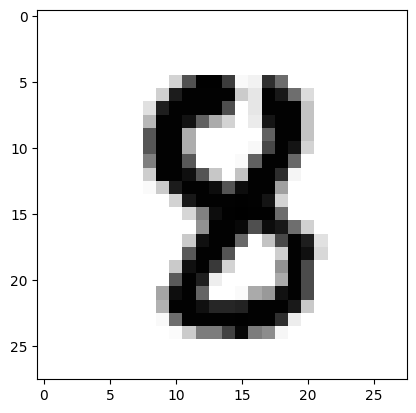

In [5]:
def plot_image(x):
  plt.imshow(x.reshape(28,28), cmap=plt.cm.binary)
  plt.show()

# Try it with your favorite number between 0 and 59999!
i_try = np.random.randint(n_train) # Random choice, but you can change it
print("I will plot a",y_train[i_try])
plot_image(x_train[i_try])

### Principal Component Analysis

We use the PCA as implemented in scikit-learn https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html. It is performed on the training set.

In [6]:
from sklearn import decomposition
pca = decomposition.PCA()
pca.fit(x_train)

PCA()

The main message of PCA is that each image is optimally approximated by the sum of $\bar{x}_n$ and a linear combination of the first $k \ll p$ principal axis $e_1, \ldots, e_k$, through the formula $$x_i \simeq \bar{x}_n + \sum_{j=1}^k \langle x_i - \bar{x}_n, e_j\rangle e_j.$$

We first plot the image $\bar{x}_n$, given by `pca.mean_`, and then the first $k=5$ principal axis, which are the first $k$ rows of the $p \times p$ array `pca.components_`.

Empirical mean:


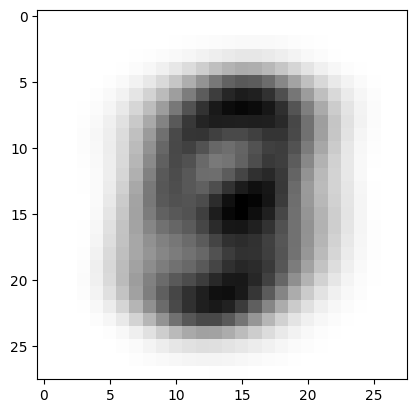

Principal axis 1 :


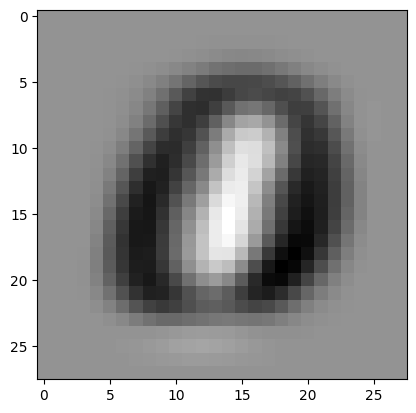

Principal axis 2 :


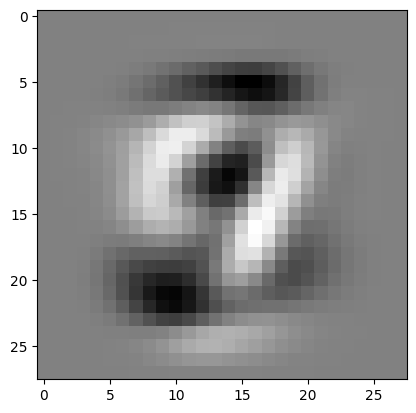

Principal axis 3 :


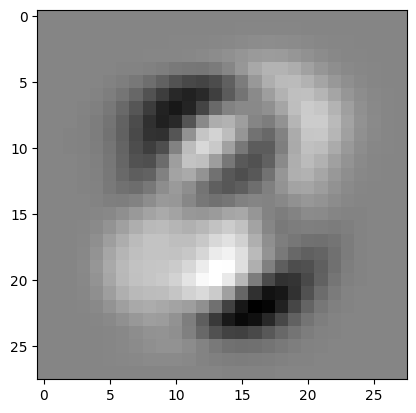

Principal axis 4 :


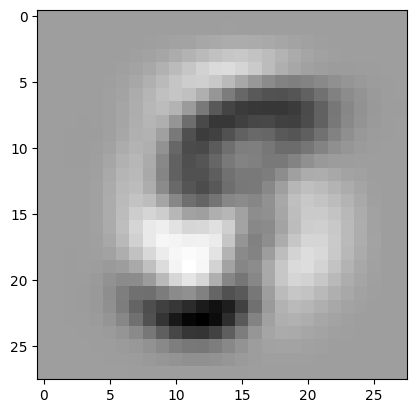

Principal axis 5 :


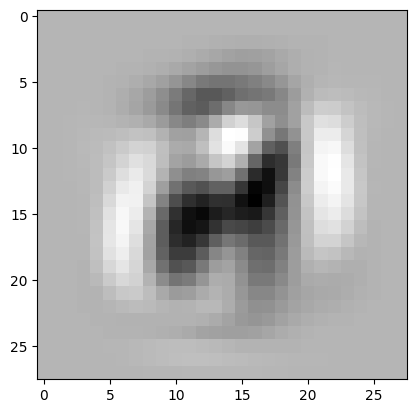

In [7]:
# Empirical mean
print("Empirical mean:")
plot_image(pca.mean_)

# First principal axis
for j in range(5):
  print("Principal axis",j+1,":")
  plot_image(pca.components_[j])

To know how many principal axes must be taken, we look at the proportion of variance explained by the first $k$ principal components. The eigenvalues of the covariance matrix are stored in the array `pca.explained_variance_`.

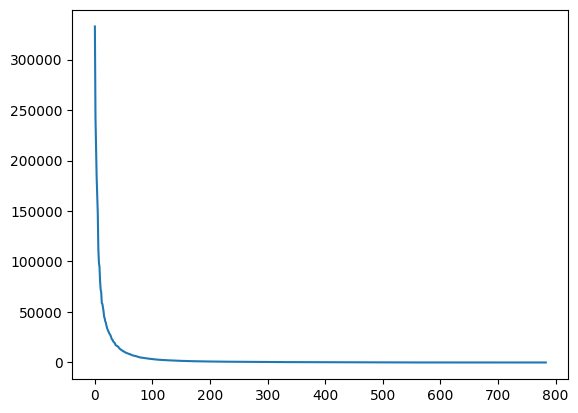

In [8]:
plt.plot(pca.explained_variance_)

**Question:** plot the proportion of variance explained by the $k$ first principal components as a function of $k$.

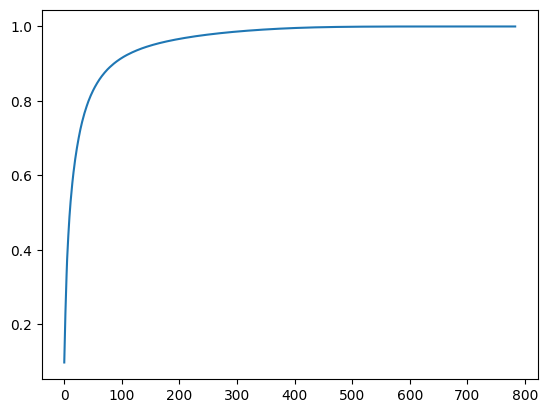

In [9]:
plt.plot(np.cumsum(pca.explained_variance_)/sum(pca.explained_variance_))

**Question:** complete the following code so that, for $q \in (0,1)$, the function `nb_comp(q)` returns the number of principal components which explains a proportion $q$ of the total variance of the training dataset.

In [10]:
def nb_comp(q):
  total = sum(pca.explained_variance_)
  sum_var = 0
  k = 0
  while sum_var < q*total:
    sum_var += pca.explained_variance_[k]
    k += 1
  return k

**Question:** what is the number of principal components to take into account to explain $90\%$ of total variance? And $99\%$?

In [11]:
print (nb_comp(0.9))
print (nb_comp(0.99))

87
331


### Dimension reduction

We now investigate the use of PCA to reduce dimensionality, in the following sense: instead of representing each picture by an array of $p=784$ pixels (most of which are white and could therefore be omitted), we represent it by the array of its scores on the first $k$ principal axes, thereby reducing the size of the data set from $n \times p$ to $n \times k$.


**Question:** complete the following code so that the function `reduce_dim(x,k)` returns the array $$x^{H_k} = \bar{x}_n + \sum_{j=1}^k \langle x-\bar{x}_n,e_j\rangle e_j,$$ with the notation of the lecture. The input $x$ should be an array of length $p$.

In [12]:
def reduce_dim(x,k):
  s = pca.mean_
  for j in range(k):
    s += np.dot(x-pca.mean_,pca.components_[j])*pca.components_[j]
  return s

  i = np.random.randint(n_train)
  for k in [10, 30, 200, 784]:
    print("Image",i,"reduced to",k,"dimensions")
    plot_image(reduce_dim(x_train[i],k))

An alternative method consists in using the methods `transform` and `inverse_transform` of the class `sklearn.decomposition.PCA`.

The method `transform` takes an array of coordinates in the canonical basis and returns the array of scores, that is to say coordinates in the basis of the principal axes. The method `inverse_transform` takes an array of scores and returns an array of coordinates in the canonical basis.

However this method requires to fix the number of components $k$ for dimension reduction when defining the object `pca` so it is longer when we try several values of $k$.

Image 26743 reduced to 10 dimensions


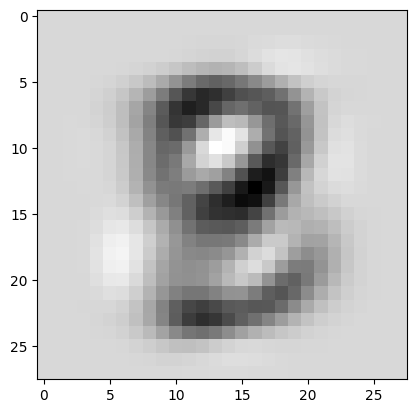

Image 26743 reduced to 30 dimensions


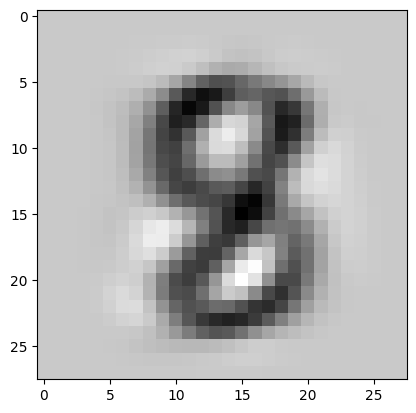

Image 26743 reduced to 200 dimensions


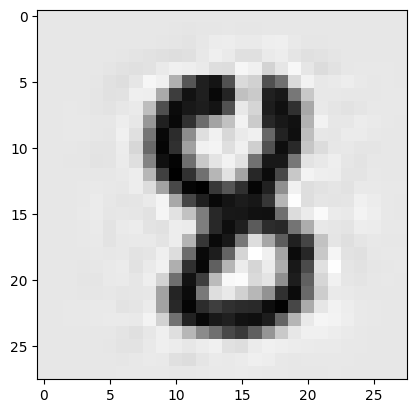

Image 26743 reduced to 784 dimensions


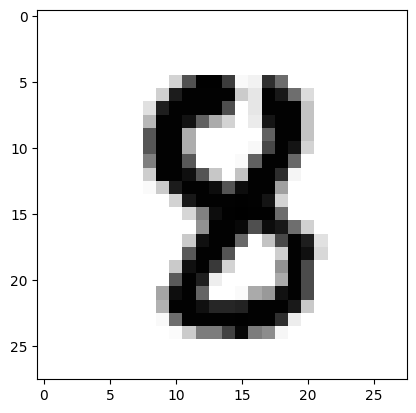

In [13]:
def reduce_dim_2(x,k):
  pca_red = decomposition.PCA(n_components=k) # Number of components for dimension reduction
  pca_red.fit(x_train)
  x_array = np.expand_dims(x, axis = 0) # Conversion into a 2-dim array, with one line
  tf = pca_red.transform(x_array) # Coordinates in the basis of the first k principal axes
  inverse_tf = pca_red.inverse_transform(tf) # Coordinates in the canonical basis
  return inverse_tf

for k in [10, 30, 200, 784]:
  print("Image",i_try,"reduced to",k,"dimensions")
  plot_image(reduce_dim_2(x_train[i_try],k))

### Projection on factorial planes

On the picture below, we plot the projection of all images from the training set onto the first factorial plane, and we assign one colour per digit $y \in \{0, \ldots, 9\}$.

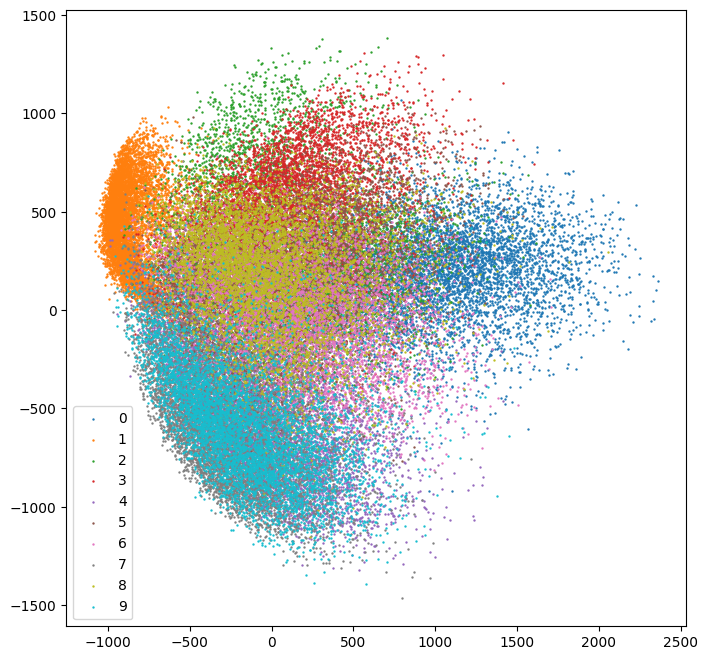

In [14]:
train_scores = pca.transform(x_train) # Array of scores of the training set
digits = range(10) # Digits between 0 and 9
colors = plt.cm.tab10(np.linspace(0, 1, 10)) # Table of colors

plt.figure(figsize=(8, 8))

# Scatter plots
for y in digits:
  indices = np.where((y_train == y))
  train_scores_extracted = train_scores[indices]
  plt.scatter(train_scores_extracted[:,0],train_scores_extracted[:,1],s=0.5,color=colors[y])
plt.legend(digits)

plt.show()

## APPLICATION: CLASSIFICATION AND CLUSTERING WITH DIMENSION REDUCTION

The goal of this part is to use PCA, performed on the training set, as a dimension reduction method to apply classification (LDA and QDA) and clustering ($k$-means) on the test set.

We first define the array of scores of PCA on the test set.

In [15]:
test_scores = pca.transform(x_test)

In both parts, you may use the function `conf_mat(y_r,y_c,vis,label_r,label_c,title)` which takes in argument two vectors `y_r` and `y_c` with the same length `n`, which both contain integers between $0$ and $9$, and returns a $10 \times 10$ matrix `mat` which contains, at the $i$-th row and $j$-th column, the number of indices `k` such that `y_r[k]==i` and `y_c[k]==j`.

If `vis==True`, the matrix is visualised (using the library `seaborn`), with labels `label_r` for the rows and `label_c` for the columns, and title `title`.

In [16]:
import seaborn as sns

In [17]:
def conf_mat(y_r,y_c,vis=False,label_r="",label_c="",title=""):
  mat = np.zeros((10,10))
  n = len(y_r)
  for k in range(n):
    mat[y_r[k],y_c[k]] = mat[y_r[k],y_c[k]] + 1
  if vis:
    plt.figure(figsize=(8, 6))
    sns.heatmap(mat, annot=True, fmt=".0f", cmap="viridis", xticklabels=digits, yticklabels=digits)
    plt.xlabel(label_c)
    plt.ylabel(label_r)
    plt.title(title)
    plt.show()
  return mat

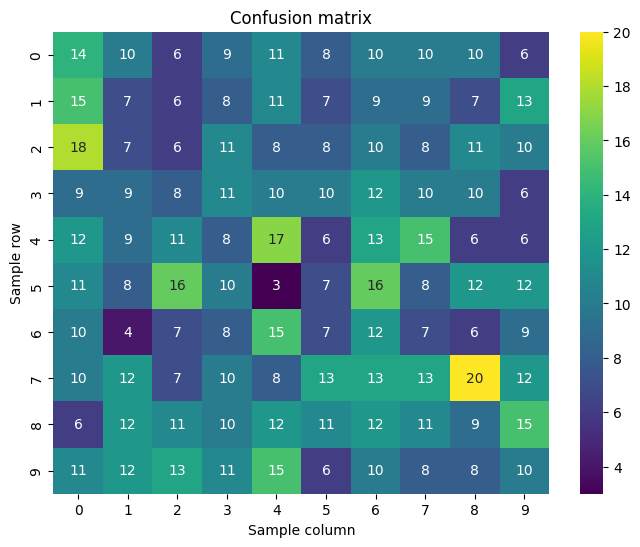

In [18]:
# Test of conf_mat
n = 1000
random_y_r = np.random.randint(10, size=n)
random_y_c = np.random.randint(10, size=n)
random_mat = conf_mat(random_y_r,random_y_c,True,"Sample row","Sample column","Confusion matrix")

The function `conf_mat()` will often be used with `y_r` a vector containing the true digit and `y_c` a vector containing the predicted digit for a set of `n` picture. In this case, the accuracy of the prediction is the proportion of correct predictions, namely the number of indices `k` such that `y_r[k]==y_c[k]`.

**Question:** write a function `accuracy(mat)` which takes in input a confusion matrix `map` returned by `conf_mat()` and returns the proportion of correct predictions.

In [19]:
def accuracy(mat):
  len_mat = 10
  s = 0
  for i in range(len_mat):
    s += mat[i,i]
  return s/np.sum(mat)

In [20]:
accuracy(random_mat)

np.float64(0.106)

### Classification with discriminant analysis

We use as features of a picture its scores on the first $k$ principal axes, and recall that LDA and QDA consist in assuming that within each class $y$, the $k$-dimensional vector of features has a Gaussian distribution with parameters $\mu_y \in \mathbb{R}^k$ and $K_y \in \mathbb{R}^{k \times k}$ (for LDA, all matrices $K_y$ are assumed to be the same). They are performed with scikit-learn: https://scikit-learn.org/stable/modules/lda_qda.html#lda-qda

In [21]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

The function `lda_predict(k)` takes in input an integer $k$ between $1$ and $p$, applies dimension reduction on the first $k$ principal axis, and applies LDA, with parameters estimated on the traning set, to the test set. It returns a vector `predict_y` of length `n_test`, such that `predict_y[i]` contains the predicted digit of the $i$-th picture in the test set.

In [22]:
def lda_predict(k):
  # Application of LDA
  lda = LinearDiscriminantAnalysis()
  lda.fit(train_scores[:,0:k], y_train) # Estimate parameters on training set (with scores on the first k principal axes as features)
  y_predict = lda.predict(test_scores[:,0:k]) # Prediction of classes on test set
  return y_predict

To test this function, we fix a value of $k$ and use `conf_mat` to compute the confusion matrix, namely the $10 \times 10$ matrix which contains, at the $i$-th row and $j$-th column, the number of pictures from the test set with true digit $i$ and predicted digit $j$.

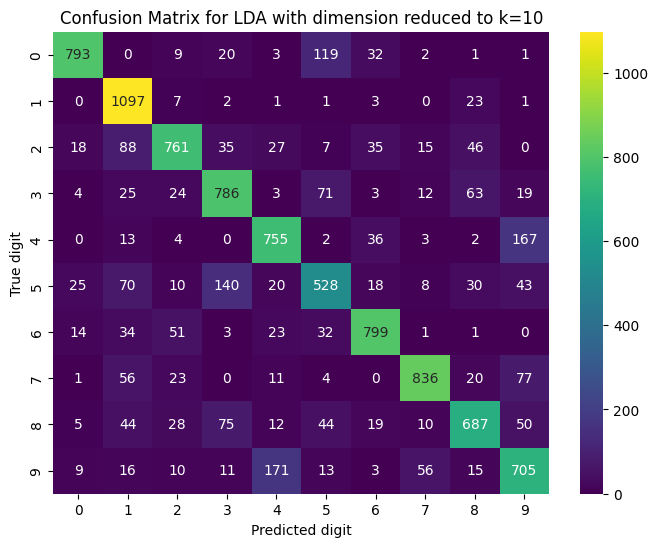

Accuracy: 0.7747


In [23]:
k=10 # Choose a value of k to try the classification

lda_mat = conf_mat(y_test,lda_predict(k),True,"True digit","Predicted digit",f"Confusion Matrix for LDA with dimension reduced to k={k}")

print("Accuracy:",accuracy(lda_mat))

**Question:** write a function `qda_predict(k)` which does the same with QDA.

In [24]:
def qda_predict(k):
  # Application of LDA
  qda = QuadraticDiscriminantAnalysis()
  qda.fit(train_scores[:,0:k], y_train) # Estimate parameters on training set (with scores on the first k principal axes as features)
  y_predict = qda.predict(test_scores[:,0:k]) # Prediction of classes on test set
  return y_predict

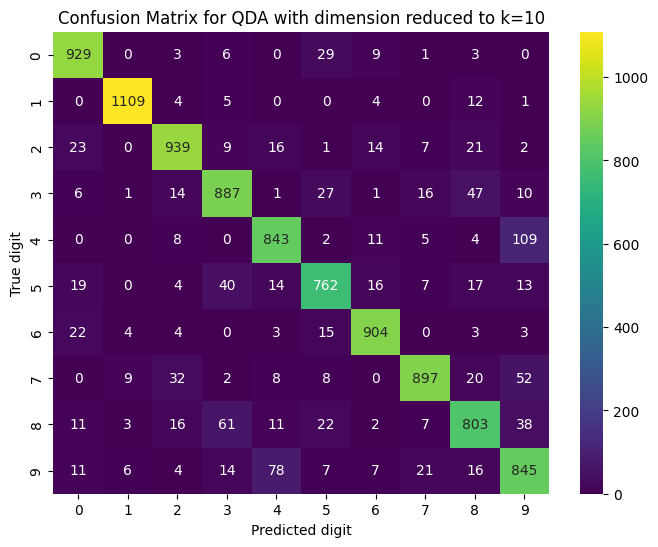

Accuracy: 0.8918


In [25]:
k=10 # Choose a value of k to try the classification

qda_mat = conf_mat(y_test,qda_predict(k),True,"True digit","Predicted digit",f"Confusion Matrix for QDA with dimension reduced to k={k}")

print("Accuracy:",accuracy(qda_mat))

**Question:** plot the accuracy (that is to say, the proportion of correction predictions on the test set) of the LDA and QDA as a function of $k$, for $k$ ranging from $1$ to $250$, and comment on the result.

*You do not need to plot it for all integer values of $k$.*

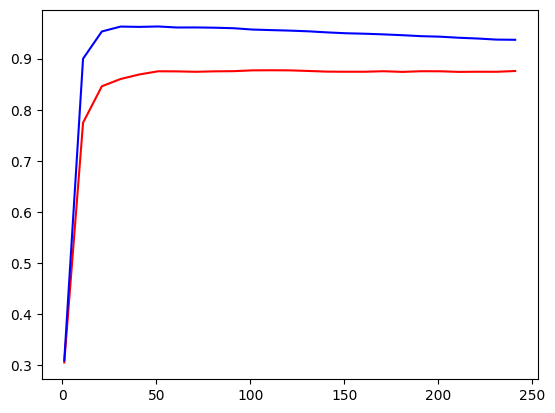

In [26]:
l_lda = []
l_qda = []
K = []
for k in range (1,251, 10):
  K.append(k)
  l_lda.append(accuracy(conf_mat(y_test,lda_predict(k),False,"","","")))
  l_qda.append(accuracy(conf_mat(y_test,qda_predict(k),False,"","","")))
plt.plot (K, l_lda, color = "r")
plt.plot(K, l_qda, color = "b")

### Clustering with $k$-means

In this part, we study the combination of dimension reduction by PCA with clustering. The goal is to apply the $k$-means algorithm to the vector of scores of the test set and assess whether clusters indeed recover actual digits. Clustering is performed with scikit-learn: https://scikit-learn.org/stable/modules/clustering.html#k-means

In [27]:
from sklearn.cluster import KMeans

The function `kmeans_predict_cluster(k)` takes in input an integer $k$ between $1$ and $p$, applies dimension reduction on the first $k$ principal axes, and applies $k$-means to the training set. The $k$-means algorithm constructs $10$ clusters, indexed from $0$ to $9$. The function `kmeans_predict_cluster(k)` returns a vector `c_predict` of length `n_test`, such that `c_predict[i]` contains the index of the cluster of the $i$-th picture in the test set.

In [28]:
def kmeans_predict_cluster(k):
  # Application of k-means
  kmeans_model = KMeans(init='k-means++', # How to compute initial centroids
                        max_iter=300, # Maximal number of iterations
                        n_clusters=10, # Number of clusters
                        n_init=20, # Number of times the algorithm is run with different initial configurations
                        random_state=0 # Set seed for reproducibility
                        )
  kmeans = kmeans_model.fit(train_scores[:,0:k])# Construct clusters on training set (with scores on the first k principal axes as features)
  c_predict = kmeans.predict(test_scores[:,0:k])# Prediction of clusters on test set

  return c_predict

We test this function for a value of $k$ as follows.

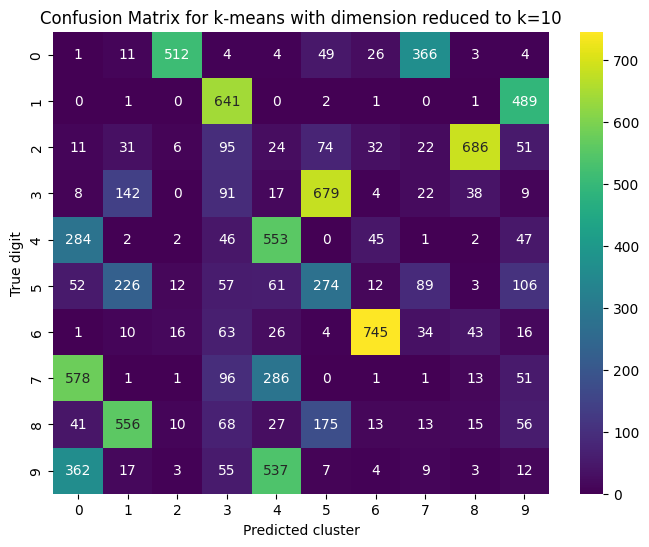

In [29]:
k=10 # Choose a value of k to try the clustering

kmeans_mat = conf_mat(y_test,kmeans_predict_cluster(k),True,"True digit","Predicted cluster",f"Confusion Matrix for k-means with dimension reduced to k={k}")

The main difference with supervised methods seen before (and the main difficulty) is that clustering does not directly predict a *digit*, but only the membership of a *cluster*. So, to assess the accuracy of the prediction, it is our job to associate each cluster with a digit. To proceed, we may:

1.   use the training set to associate each cluster with a digit, for example the one which is the most present in the cluster;
2.   compute the accuracy of the prediction on the test set to compare with supervised methods.

**Question:** modify the code of the function `kmeans_predict_cluster(k)` to define a function `kmeans_predict_digit(k)` which returns the vector `y_predict`, of length `n_test`, such that `y_predict[i]` contains the predicted digit for the $i$-th picture of the test set.

In [30]:
def kmeans_predict_digit(k):

  kmeans_model = KMeans(init='k-means++',
                        max_iter=300,
                        n_clusters=10,
                        n_init=20,
                        random_state=0
                        )
  kmeans = kmeans_model.fit(train_scores[:,0:k])

  cluster_to_digit = {}
  for cluster_idx in range(10):

    indices = np.where(kmeans.labels_ == cluster_idx)[0]

    true_digits_in_cluster = y_train[indices]

    if len(true_digits_in_cluster) > 0:
      most_frequent_digit = np.bincount(true_digits_in_cluster).argmax()
      cluster_to_digit[cluster_idx] = most_frequent_digit
    else:
      cluster_to_digit[cluster_idx] = -1
  c_predict = kmeans.predict(test_scores[:,0:k])

  y_predict = np.array([cluster_to_digit.get(cluster, -1) for cluster in c_predict])
  return y_predict

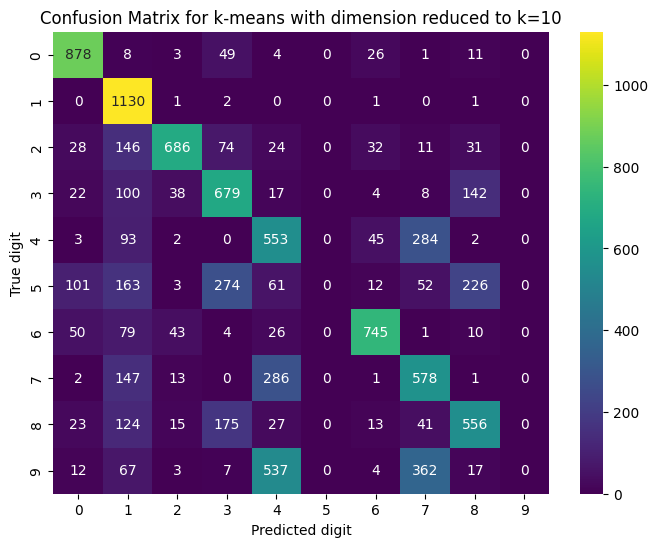

Accuracy: 0.5805


In [31]:
k=10 # Choose a value of k to try the clustering

kmeans_mat = conf_mat(y_test,kmeans_predict_digit(k),True,"True digit","Predicted digit",f"Confusion Matrix for k-means with dimension reduced to k={k}")

print("Accuracy:",accuracy(kmeans_mat))

**Question:** plot the accuracy as a function of $k$, for $k$ ranging from $1$ to $250$, and compare the results with supervised methods.

In [ ]:
l_kmeans = []
# K is already defined from the previous LDA/QDA plot
for k_val in K:
  kmeans_mat = conf_mat(y_test, kmeans_predict_digit(k_val), False, "", "", "")
  l_kmeans.append(accuracy(kmeans_mat))

plt.figure(figsize=(10, 6))
plt.plot(K, l_lda, color="r", label="LDA Accuracy")
plt.plot(K, l_qda, color="b", label="QDA Accuracy")
plt.plot(K, l_kmeans, color="g", label="K-means Accuracy")
plt.xlabel("Number of Principal Components (k)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Number of Principal Components for LDA, QDA, and K-means")
plt.legend()
plt.grid(True)
plt.show()

In your report, you will present the principle of dimension reduction, LDA/QDA and clustering by $k$-means. You will in particular describe the differences between supervised and unsupervised. You will then report on the numerical experiences of the Application part and your conclusions and comments. Feel free to carry out further experiments!